# Q1) The Probability of Shooting at a Target

A point is chosen at random from a disk of radius $10$. Let $A$ be the event that the point lies within $1$ unit of the boundary.

1. Model the experiment assuming the point is uniformly distributed with respect to area, and compute $P(A)$.
2. Model the experiment assuming the distance to the point from the center is chosen uniformly from $[0,10]$, and the direction is chosen independently and uniformly from $[0,2\pi)$ and compute $P(A)$.
3. Explain why the two answers differ.


Model 1 (Uniform Area) - Theoretical P(A): 0.190
Model 1 (Uniform Area) - Simulated P(A):  0.191

Model 2 (Uniform Distance) - Theoretical P(A): 0.100
Model 2 (Uniform Distance) - Simulated P(A):  0.104


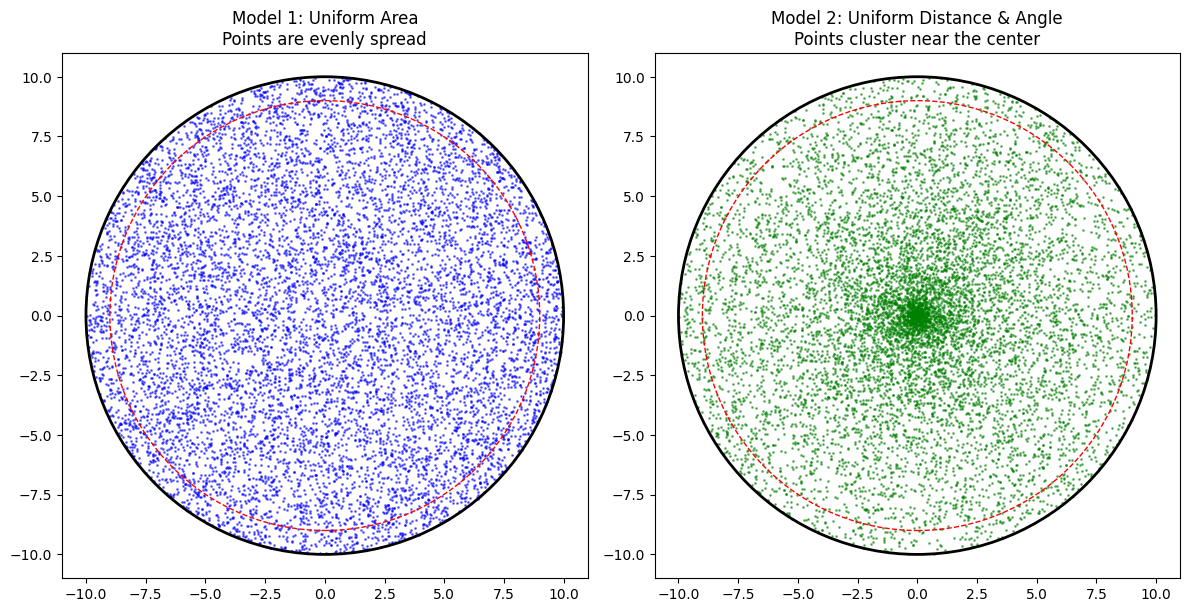

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Set the number of random points to generate
n_points = 10000
radius = 10

# ==========================================
# MODEL 1: Uniformly Distributed by Area
# ==========================================
# To get a uniform area distribution, we take the square root of the random variable for radius
r1 = radius * np.sqrt(np.random.uniform(0, 1, n_points))
theta1 = np.random.uniform(0, 2*np.pi, n_points)

# Convert to Cartesian coordinates for plotting
x1 = r1 * np.cos(theta1)
y1 = r1 * np.sin(theta1)

# Calculate empirical probability for Model 1
prob1 = np.sum(r1 >= 9) / n_points

# ==========================================
# MODEL 2: Uniform Radius and Angle
# ==========================================
# Radius is chosen uniformly from [0, 10]
r2 = np.random.uniform(0, radius, n_points)
theta2 = np.random.uniform(0, 2*np.pi, n_points)

# Convert to Cartesian coordinates for plotting
x2 = r2 * np.cos(theta2)
y2 = r2 * np.sin(theta2)

# Calculate empirical probability for Model 2
prob2 = np.sum(r2 >= 9) / n_points

# ==========================================
# Output & Visualization
# ==========================================
print(f"Model 1 (Uniform Area) - Theoretical P(A): 0.190")
print(f"Model 1 (Uniform Area) - Simulated P(A):  {prob1:.3f}\n")

print(f"Model 2 (Uniform Distance) - Theoretical P(A): 0.100")
print(f"Model 2 (Uniform Distance) - Simulated P(A):  {prob2:.3f}")

# Plotting the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot 1
ax1.scatter(x1, y1, s=1, alpha=0.5, color='blue')
ax1.add_patch(plt.Circle((0, 0), radius, color='black', fill=False, linewidth=2))
ax1.add_patch(plt.Circle((0, 0), 9, color='red', fill=False, linewidth=1, linestyle='--'))
ax1.set_title('Model 1: Uniform Area\nPoints are evenly spread')
ax1.set_aspect('equal')
ax1.set_xlim(-11, 11)
ax1.set_ylim(-11, 11)

# Plot 2
ax2.scatter(x2, y2, s=1, alpha=0.5, color='green')
ax2.add_patch(plt.Circle((0, 0), radius, color='black', fill=False, linewidth=2))
ax2.add_patch(plt.Circle((0, 0), 9, color='red', fill=False, linewidth=1, linestyle='--'))
ax2.set_title('Model 2: Uniform Distance & Angle\nPoints cluster near the center')
ax2.set_aspect('equal')
ax2.set_xlim(-11, 11)
ax2.set_ylim(-11, 11)

plt.tight_layout()
plt.show()

The two models define "random" in fundamentally different ways, which changes the probability density of the radial distance $r$.

In Model 1 (Uniform Area): A thin ring of width $dr$ near the edge of the disk has a much larger area ($2\pi r \cdot dr$) than a thin ring of the same width near the center. Because probability is tied to area, points are geometrically more likely to land further away from the center. The probability density function for the radius is $f(r) = \frac{2r}{100}$, which increases linearly as you move outward.

In Model 2 (Uniform Distance/Angle): By picking the radius $r$ uniformly from $[0,10]$, you are forcing a thin ring near the center to have the exact same number of points as a thin ring near the boundary. Because the center ring has much less area, the points end up heavily clustered and crowded near the center of the disk, and sparsely spread out near the edges.

# Q2) Bertrand's Paradox

A chord of a circle is chosen “at random.” What is the probability that its length exceeds the side length of the inscribed equilateral triangle?

Show that different mathematically natural models of “random chord” lead to different answers.

--- Bertrand's Paradox Simulations ---
Method 1 (Random Endpoints) : Expected = 0.333, Simulated = 0.342
Method 2 (Random Radius)    : Expected = 0.500, Simulated = 0.496
Method 3 (Random Area)      : Expected = 0.250, Simulated = 0.243


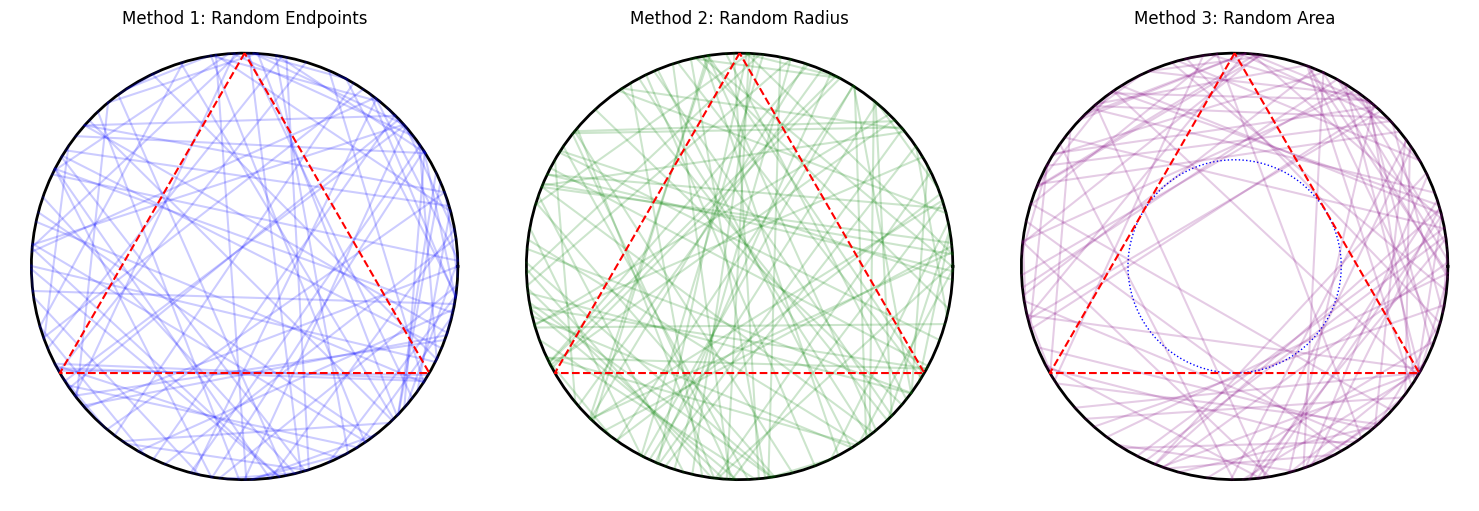

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Set parameters
N = 10000  # Number of chords to simulate
R = 1      # Radius of the circle
target_length = R * np.sqrt(3) # Side of inscribed equilateral triangle

# ==========================================
# METHOD 1: Random Endpoints
# ==========================================
theta1 = np.random.uniform(0, 2*np.pi, N)
theta2 = np.random.uniform(0, 2*np.pi, N)
# Chord length formula: 2 * R * sin(|theta1 - theta2| / 2)
lengths_1 = 2 * R * np.abs(np.sin((theta1 - theta2) / 2))
prob_1 = np.sum(lengths_1 > target_length) / N

# ==========================================
# METHOD 2: Random Radial Point
# ==========================================
# Midpoint distance chosen uniformly from [0, R]
r_mid_2 = np.random.uniform(0, R, N)
# Chord length formula using Pythagorean theorem
lengths_2 = 2 * np.sqrt(R**2 - r_mid_2**2)
prob_2 = np.sum(lengths_2 > target_length) / N

# ==========================================
# METHOD 3: Random Midpoint (Area)
# ==========================================
# Midpoint chosen uniformly over the area (sqrt of uniform for radius)
r_mid_3 = R * np.sqrt(np.random.uniform(0, 1, N))
lengths_3 = 2 * np.sqrt(R**2 - r_mid_3**2)
prob_3 = np.sum(lengths_3 > target_length) / N

# ==========================================
# Output Results
# ==========================================
print("--- Bertrand's Paradox Simulations ---")
print(f"Method 1 (Random Endpoints) : Expected = 0.333, Simulated = {prob_1:.3f}")
print(f"Method 2 (Random Radius)    : Expected = 0.500, Simulated = {prob_2:.3f}")
print(f"Method 3 (Random Area)      : Expected = 0.250, Simulated = {prob_3:.3f}")

# ==========================================
# Visualization (Plotting 100 chords for each to see density)
# ==========================================
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
titles = ['Method 1: Random Endpoints', 'Method 2: Random Radius', 'Method 3: Random Area']
theta_circle = np.linspace(0, 2*np.pi, 100)

for i, ax in enumerate(axs):
    ax.plot(R * np.cos(theta_circle), R * np.sin(theta_circle), 'k-', lw=2) # Draw circle

    # Draw Inscribed Triangle for reference
    tri_angles = [np.pi/2, np.pi/2 + 2*np.pi/3, np.pi/2 + 4*np.pi/3, np.pi/2]
    ax.plot(R * np.cos(tri_angles), R * np.sin(tri_angles), 'r--', lw=1.5, zorder=3)

    # Draw concentric circle for Method 3 reference
    if i == 2:
        ax.plot((R/2) * np.cos(theta_circle), (R/2) * np.sin(theta_circle), 'b:', lw=1)

    ax.set_aspect('equal')
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_title(titles[i])
    ax.axis('off')

# Plot 100 sample chords for Method 1
for i in range(100):
    x = [R * np.cos(theta1[i]), R * np.cos(theta2[i])]
    y = [R * np.sin(theta1[i]), R * np.sin(theta2[i])]
    axs[0].plot(x, y, color='blue', alpha=0.2)

# Plot 100 sample chords for Method 2
theta_rad = np.random.uniform(0, 2*np.pi, 100) # Random angle for the radius itself
for i in range(100):
    # Midpoint coordinates
    mx = r_mid_2[i] * np.cos(theta_rad[i])
    my = r_mid_2[i] * np.sin(theta_rad[i])
    # Half-chord length
    half_L = np.sqrt(R**2 - r_mid_2[i]**2)
    # Chord endpoints (perpendicular to radius)
    dx = -half_L * np.sin(theta_rad[i])
    dy = half_L * np.cos(theta_rad[i])
    axs[1].plot([mx - dx, mx + dx], [my - dy, my + dy], color='green', alpha=0.2)

# Plot 100 sample chords for Method 3
theta_mid = np.random.uniform(0, 2*np.pi, 100)
for i in range(100):
    mx = r_mid_3[i] * np.cos(theta_mid[i])
    my = r_mid_3[i] * np.sin(theta_mid[i])
    half_L = np.sqrt(R**2 - r_mid_3[i]**2)
    # Perpendicular direction
    dx = -half_L * np.sin(theta_mid[i])
    dy = half_L * np.cos(theta_mid[i])
    axs[2].plot([mx - dx, mx + dx], [my - dy, my + dy], color='purple', alpha=0.2)

plt.tight_layout()
plt.show()

The paradox isn't actually a paradox; it's a demonstration of ill-posed problems. The term "random chord" is ambiguous. Each method assumes a different uniformity:

Method 1 assumes uniformity over the circumference.

Method 2 assumes uniformity over a linear radius.

Method 3 assumes uniformity over the area.

Depending on the physical mechanism used to generate the chord (e.g., throwing straws on a circle vs. spinning a pointer), a different method would apply.

#Q8) Probability of Being a Girl?

A family has two children. Assume each child is equally likely to be a boy or a girl, independently of the other.

What is the probability that both children are girls, given that **at least one** of them is a girl?

Total families simulated: 100000
Families with at least one girl: 75274
Families with two girls (given at least one): 25201
---
Empirical Probability: 0.3348
Theoretical Probability: 0.3333


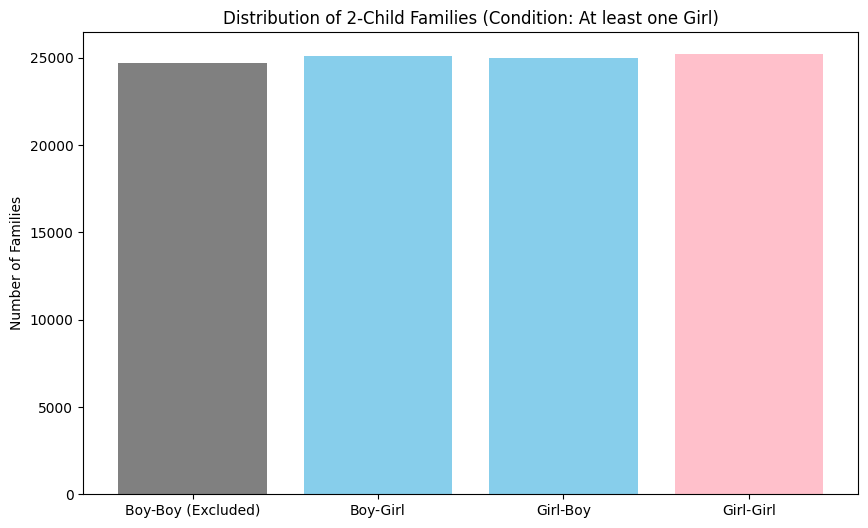

In [7]:
import pandas as pd
import numpy as np

# 1. Simulate 100,000 families with two children
n_families = 100000
# 0 = Boy, 1 = Girl
child1 = np.random.randint(0, 2, n_families)
child2 = np.random.randint(0, 2, n_families)

df = pd.DataFrame({
    'Child1': child1,
    'Child2': child2
})

# 2. Apply the condition: At least one is a girl (1)
# This means (Child1 == 1) OR (Child2 == 1)
at_least_one_girl = df[(df['Child1'] == 1) | (df['Child2'] == 1)]

# 3. Calculate how many of those filtered families have two girls
both_girls = at_least_one_girl[(at_least_one_girl['Child1'] == 1) & (at_least_one_girl['Child2'] == 1)]

# 4. Compute Probability
prob = len(both_girls) / len(at_least_one_girl)

print(f"Total families simulated: {n_families}")
print(f"Families with at least one girl: {len(at_least_one_girl)}")
print(f"Families with two girls (given at least one): {len(both_girls)}")
print(f"---")
print(f"Empirical Probability: {prob:.4f}")
print(f"Theoretical Probability: {1/3:.4f}")

# Optional: Visualize the outcomes
import matplotlib.pyplot as plt

counts = [
    len(df[(df['Child1'] == 0) & (df['Child2'] == 0)]), # BB
    len(df[(df['Child1'] == 0) & (df['Child2'] == 1)]), # BG
    len(df[(df['Child1'] == 1) & (df['Child2'] == 0)]), # GB
    len(df[(df['Child1'] == 1) & (df['Child2'] == 1)])  # GG
]

labels = ['Boy-Boy (Excluded)', 'Boy-Girl', 'Girl-Boy', 'Girl-Girl']
colors = ['gray', 'skyblue', 'skyblue', 'pink']

plt.figure(figsize=(10, 6))
plt.bar(labels, counts, color=colors)
plt.title("Distribution of 2-Child Families (Condition: At least one Girl)")
plt.ylabel("Number of Families")
plt.show()

# Q9) Information Available in a Discrete Random Variable

A factory inspects a product and records its quality using two different coding systems.

Each product falls into exactly one of the following four categories:

* $G_1$: good quality, produced on Machine 1
* $G_2$: good quality, produced on Machine 2
* $D_1$: defective, produced on Machine 1
* $D_2$: defective, produced on Machine 2

Assume the sample space is

$$
\Omega=\{G_1,G_2,D_1,D_2\},
$$

with probabilities

$$
P(\{G_1\})=0.50,\qquad P(\{G_2\})=0.20,\qquad P(\{D_1\})=0.10,\qquad P(\{D_2\})=0.20.
$$

Define two discrete random variables on the same probability space:

* $X$ records only whether the item is good or defective:
  $$
  X(G_1)=0,\quad X(G_2)=0,\quad X(D_1)=1,\quad X(D_2)=1.
  $$

* $Y$ records both quality and machine:
  $$
  Y(G_1)=1,\quad Y(G_2)=2,\quad Y(D_1)=3,\quad Y(D_2)=4.
  $$

Answer the following.

1. Write down the probability space $(\Omega,\mathfrak F,P)$, where $\mathfrak F=\mathfrak P(\Omega)$.

2. Compute the $\sigma$-algebra generated by $X$, namely $\sigma(X)$.

3. Compute the $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$.

4. Show that $\sigma(X)\subseteq \sigma(Y)$, and explain why $Y$ contains more information than $X$.

5. Find the marginal distribution of $X$.

6. Find the marginal distribution of $Y$.

7. Compute the joint probabilities
   $$
   P(X=0,Y=1),\quad P(X=0,Y=2),\quad P(X=1,Y=3),\quad P(X=1,Y=4).
   $$

8. Compute the conditional probabilities
   $$
   P(X=1\mid Y=3),\qquad P(X=1\mid Y=4),\qquad P(Y=3\mid X=1),\qquad P(Y=4\mid X=1).
   $$

9. Interpret the difference between conditioning on $X$ and conditioning on $Y$.

10. Explain, in words, what information is available in $\sigma(X)$ but not in $\sigma(Y)$, and what information is available in $\sigma(Y)$ but not in $\sigma(X)$.

11. Give a Python based visualization of the model.

12. Find the marginal, joint, and conditional Shannon Entropy of $X$ and $Y$.

--- Sigma-Algebras ---
Size of sigma(X): 4 elements
Size of sigma(Y): 16 elements
Is sigma(X) a subset of sigma(Y)? True

--- Probabilities ---
P(X=0): 0.70, P(X=1): 0.30
P(X=1|Y=3): 1.00
P(Y=3|X=1): 0.33

--- Information Theory (Entropy) ---
H(X): 0.8813 bits
H(Y): 1.7610 bits
H(Y|X): 0.8797 bits (Uncertainty about machine given quality)


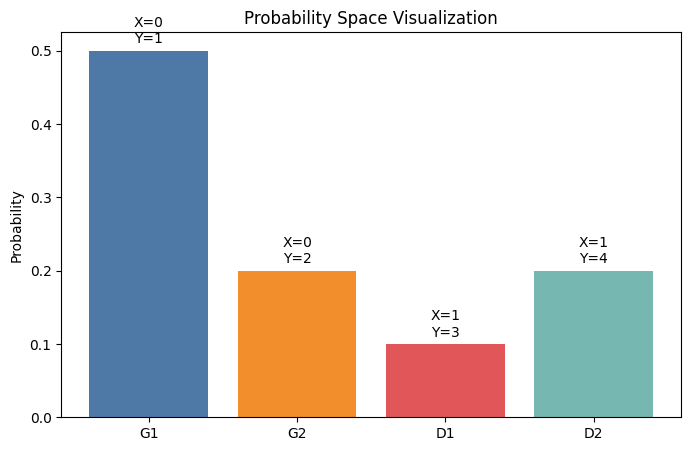

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import chain, combinations

# ---------------------------------------------------------
# 1. Setup the Probability Space (Q9.1)
# ---------------------------------------------------------
omega = {'G1': 0.50, 'G2': 0.20, 'D1': 0.10, 'D2': 0.20}

# ---------------------------------------------------------
# 2. Define Random Variables X and Y (Q9.2, Q9.3)
# ---------------------------------------------------------
# X: Good (0) vs Defective (1)
X_map = {'G1': 0, 'G2': 0, 'D1': 1, 'D2': 1}
# Y: Full resolution (1, 2, 3, 4)
Y_map = {'G1': 1, 'G2': 2, 'D1': 3, 'D2': 4}

def get_sigma_algebra(rv_map):
    # Groups outcomes by the value the RV takes
    inverse_images = {}
    for outcome, value in rv_map.items():
        if value not in inverse_images:
            inverse_images[value] = set()
        inverse_images[value].add(outcome)

    # Generate all unions of these atoms (the sigma-algebra)
    atoms = list(inverse_images.values())
    sigma_algebra = []
    for r in range(len(atoms) + 1):
        for combo in combinations(atoms, r):
            # Flatten the tuple of sets into a single frozen set
            sigma_algebra.append(frozenset().union(*combo))
    return sigma_algebra

sigma_X = get_sigma_algebra(X_map)
sigma_Y = get_sigma_algebra(Y_map)

# ---------------------------------------------------------
# 3. Probabilities and Distributions (Q9.5, Q9.6, Q9.7, Q9.8)
# ---------------------------------------------------------
# Marginals
p_x0 = sum(p for out, p in omega.items() if X_map[out] == 0)
p_x1 = sum(p for out, p in omega.items() if X_map[out] == 1)

p_y = {val: sum(p for out, p in omega.items() if Y_map[out] == val) for val in [1,2,3,4]}

# Joint Probabilities
p_x1_y3 = omega['D1'] if (X_map['D1']==1 and Y_map['D1']==3) else 0
p_x1_y4 = omega['D2'] if (X_map['D2']==1 and Y_map['D2']==4) else 0

# Conditionals
cond_x1_y3 = p_x1_y3 / p_y[3]
cond_y3_x1 = p_x1_y3 / p_x1

# ---------------------------------------------------------
# 4. Shannon Entropy Calculations (Q9.12)
# ---------------------------------------------------------
def entropy(probs):
    probs = np.array(probs)
    return -np.sum(probs[probs>0] * np.log2(probs[probs>0]))

h_x = entropy([p_x0, p_x1])
h_y = entropy(list(p_y.values()))
# H(X,Y) is essentially H(Y) because Y determines X
h_joint = h_y
h_x_given_y = h_joint - h_y
h_y_given_x = h_joint - h_x

# ---------------------------------------------------------
# 5. Output Results
# ---------------------------------------------------------
print(f"--- Sigma-Algebras ---")
print(f"Size of sigma(X): {len(sigma_X)} elements")
print(f"Size of sigma(Y): {len(sigma_Y)} elements")
print(f"Is sigma(X) a subset of sigma(Y)? {set(sigma_X).issubset(set(sigma_Y))}")

print(f"\n--- Probabilities ---")
print(f"P(X=0): {p_x0:.2f}, P(X=1): {p_x1:.2f}")
print(f"P(X=1|Y=3): {cond_x1_y3:.2f}")
print(f"P(Y=3|X=1): {cond_y3_x1:.2f}")

print(f"\n--- Information Theory (Entropy) ---")
print(f"H(X): {h_x:.4f} bits")
print(f"H(Y): {h_y:.4f} bits")
print(f"H(Y|X): {h_y_given_x:.4f} bits (Uncertainty about machine given quality)")

# ---------------------------------------------------------
# 6. Visualization (Q9.11)
# ---------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']
ax.bar(omega.keys(), omega.values(), color=colors)
ax.set_title("Probability Space Visualization")
ax.set_ylabel("Probability")
for i, v in enumerate(omega.values()):
    ax.text(i, v + 0.01, f"X={X_map[list(omega.keys())[i]]}\nY={Y_map[list(omega.keys())[i]]}", ha='center')
plt.show()

Metric                    | Value (Bits)
----------------------------------------
Entropy H(X)              | 0.8813
Entropy H(Y)              | 1.7610
Joint Entropy H(X,Y)      | 1.7610
Conditional H(X|Y)        | 0.0000
Conditional H(Y|X)        | 0.8797


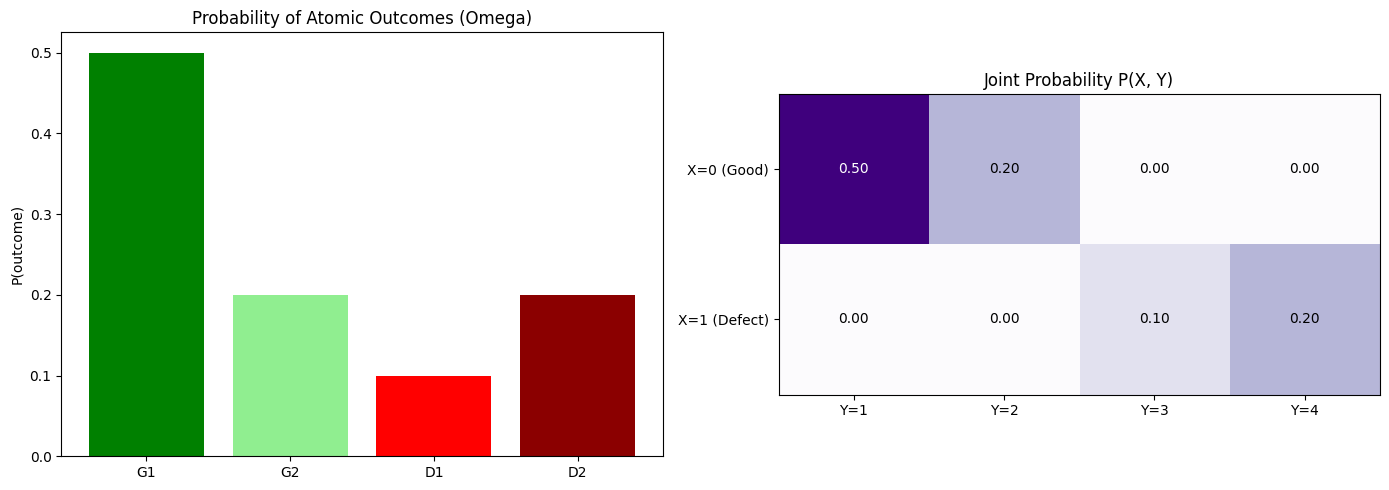

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Define the model
outcomes = ['G1', 'G2', 'D1', 'D2']
probs = np.array([0.5, 0.2, 0.1, 0.2])
X_map = {'G1': 0, 'G2': 0, 'D1': 1, 'D2': 1}
Y_map = {'G1': 1, 'G2': 2, 'D1': 3, 'D2': 4}

# 2. Entropy Function
def shannon_entropy(p_array):
    p = p_array[p_array > 0] # Remove zeros for log calculation
    return -np.sum(p * np.log2(p))

# 3. Calculations
marginal_x = np.array([0.7, 0.3])
marginal_y = probs
# Joint P(X,Y) matrix
joint_xy = np.zeros((2, 5)) # Indices 0,1 for X and 1,2,3,4 for Y
for i, out in enumerate(outcomes):
    joint_xy[X_map[out], Y_map[out]] = probs[i]

h_x = shannon_entropy(marginal_x)
h_y = shannon_entropy(marginal_y)
h_joint = shannon_entropy(joint_xy.flatten())
h_x_given_y = h_joint - h_y
h_y_given_x = h_joint - h_x

# 4. Display Results
print(f"{'Metric':<25} | {'Value (Bits)':<10}")
print("-" * 40)
print(f"{'Entropy H(X)':<25} | {h_x:.4f}")
print(f"{'Entropy H(Y)':<25} | {h_y:.4f}")
print(f"{'Joint Entropy H(X,Y)':<25} | {h_joint:.4f}")
print(f"{'Conditional H(X|Y)':<25} | {h_x_given_y:.4f}")
print(f"{'Conditional H(Y|X)':<25} | {h_y_given_x:.4f}")

# 5. Visualization
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot Probabilities
ax[0].bar(['G1', 'G2', 'D1', 'D2'], probs, color=['green', 'lightgreen', 'red', 'darkred'])
ax[0].set_title("Probability of Atomic Outcomes (Omega)")
ax[0].set_ylabel("P(outcome)")

# Plot Joint Distribution Heatmap
im = ax[1].imshow(joint_xy[:, 1:], cmap='Purples')
ax[1].set_xticks([0, 1, 2, 3])
ax[1].set_xticklabels(['Y=1', 'Y=2', 'Y=3', 'Y=4'])
ax[1].set_yticks([0, 1])
ax[1].set_yticklabels(['X=0 (Good)', 'X=1 (Defect)'])
ax[1].set_title("Joint Probability P(X, Y)")

# Add text to heatmap
for i in range(2):
    for j in range(4):
        val = joint_xy[i, j+1]
        ax[1].text(j, i, f'{val:.2f}', ha='center', va='center', color='black' if val < 0.4 else 'white')

plt.tight_layout()
plt.show()

# Q10) Information Available in Continuous Random Varaibles

A chemical plant monitors each production run using two different measurement systems.

For a given run, let

* $T$ be the deviation of the reactor temperature from target, measured in standardized units,
* $P$ be the deviation of the reactor pressure from target, also measured in standardized units.

Assume that $(T,P)$ is jointly continuous, with independent normal components:

$$
T \sim N(0,1), \qquad P \sim N(0,4),
$$

and $T$ and $P$ are independent.

Let the underlying probability space be

$$
\Omega=\mathbb R^2, \qquad \mathfrak F=\mathfrak B(\mathbb R^2),
$$

and let $P$ be the probability measure induced by the joint density

$$
f_{T,P}(t,p)=\frac{1}{4\pi}\exp\left(-\frac{t^2}{2}-\frac{p^2}{8}\right), \qquad (t,p)\in\mathbb R^2.
$$

Define two random variables on the same probability space:

* $X:\Omega\to\mathbb R$ by
  $$
  X(t,p)=t,
  $$
  so that $X$ records only the reactor temperature deviation;

* $Y:\Omega\to\mathbb R^2$ by
  $$
  Y(t,p)=(t,p),
  $$
  so that $Y$ records the full sensor state: both temperature and pressure deviations.

Answer the following.

1. Write down the probability space $(\Omega,\mathfrak F,P)$ explicitly.

2. Compute the $\sigma$-algebra generated by $X$, namely $\sigma(X)$.

3. Compute the $\sigma$-algebra generated by $Y$, namely $\sigma(Y)$.

4. Show that
   $$
   \sigma(X)\subseteq \sigma(Y),
   $$
   and explain why $Y$ contains more information than $X$.

5. Find the marginal density of $X$.

6. Find the marginal density of $Y$.

7. Compute the following probabilities:
   $$
   P(X\leq 0), \qquad P(X>1), \qquad P(Y\in (-\infty,0]\times\mathbb R), \qquad P(Y\in [ -1,1]\times[-2,2]).
   $$

8. Compute the conditional distribution of $X$ given $Y=(t,p)$.

9. Compute the conditional distribution of $Y$ given $X=t$.

10. Explain, in words, what is known when one conditions on $X$ and what additional information becomes available when one conditions on $Y$.

11. Show that
    $$
    X=\pi_1\circ Y,
    $$
    where $\pi_1(t,p)=t$, and explain why this implies that $X$ is a measurable function of $Y$.

12. Give a Python-based visualization of the model, for example by plotting:

* the joint density of $Y=(T,P)$ as a contour plot or heat map;
* the marginal density of $X$;
* and a diagram illustrating that $\sigma(X)$ is coarser than $\sigma(Y)$.

13. Compute the differential entropy of $X$:

$$
h(X)=-\int_{\mathbb R} f_X(x)\ln f_X(x)\,dx.
$$

14. Compute the differential entropy of $Y$:

$$
h(Y)=-\int_{\mathbb R^2} f_Y(t,p)\ln f_Y(t,p)\,dt\,dp.
$$

15. Compute the conditional differential entropy

$$
h(Y|X),
$$

and interpret it physically.

16. Discuss what happens to

$$
h(X|Y)
$$

in this model, and explain why the continuous case differs from the discrete case when one random variable is completely determined by the other.


Differential Entropy h(X): 1.4189 nats
Differential Entropy h(Y): 3.5310 nats
Conditional Entropy h(Y|X): 2.1121 nats


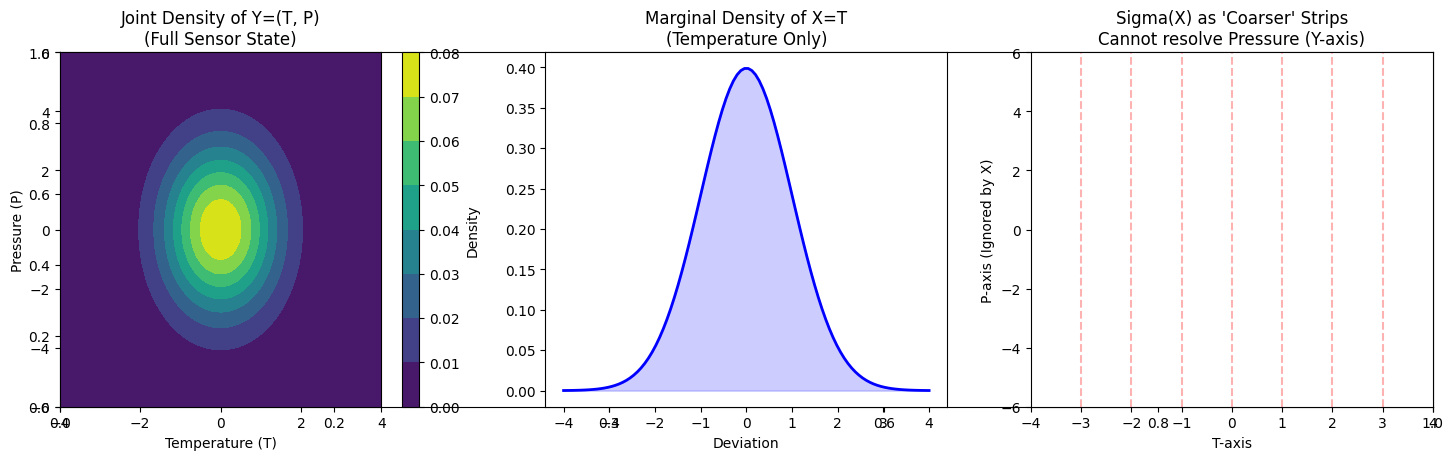

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal

# 1. Parameters
mu = [0, 0]
cov = [[1, 0], [0, 4]] # T var=1, P var=4

# 2. Entropy Calculations (Nats)
h_x = 0.5 * np.log(2 * np.pi * np.e * 1)
h_p = 0.5 * np.log(2 * np.pi * np.e * 4)
h_y = h_x + h_p

print(f"Differential Entropy h(X): {h_x:.4f} nats")
print(f"Differential Entropy h(Y): {h_y:.4f} nats")
print(f"Conditional Entropy h(Y|X): {h_p:.4f} nats")

# 3. Visualization
x = np.linspace(-4, 4, 100)
y = np.linspace(-6, 6, 100)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))
rv = multivariate_normal(mu, cov)
Z = rv.pdf(pos)

fig = plt.subplots(figsize=(15, 5))

# Plot A: Joint Density (Y)
plt.subplot(1, 3, 1)
plt.contourf(X, Y, Z, cmap='viridis')
plt.colorbar(label='Density')
plt.title("Joint Density of Y=(T, P)\n(Full Sensor State)")
plt.xlabel("Temperature (T)")
plt.ylabel("Pressure (P)")

# Plot B: Marginal Density (X)
plt.subplot(1, 3, 2)
plt.plot(x, norm.pdf(x, 0, 1), color='blue', lw=2)
plt.fill_between(x, norm.pdf(x, 0, 1), color='blue', alpha=0.2)
plt.title("Marginal Density of X=T\n(Temperature Only)")
plt.xlabel("Deviation")

# Plot C: Sigma-Algebra Illustration
plt.subplot(1, 3, 3)
# Representing sigma(X) as vertical partitions (strips)
for i in range(-3, 4):
    plt.axvline(i, color='red', alpha=0.3, linestyle='--')
plt.title("Sigma(X) as 'Coarser' Strips\nCannot resolve Pressure (Y-axis)")
plt.xlabel("T-axis")
plt.ylabel("P-axis (Ignored by X)")
plt.xlim(-4, 4)
plt.ylim(-6, 6)

plt.tight_layout()
plt.show()

1. Probability Space $(\Omega, \mathcal{F}, P)$$\Omega$: $\mathbb{R}^2$ (the set of all possible pairs of temperature and pressure deviations).$\mathcal{F}$: $\mathcal{B}(\mathbb{R}^2)$, the Borel $\sigma$-algebra on $\mathbb{R}^2$.$P$: The probability measure defined by the joint PDF $f_{T,P}(t,p) = \frac{1}{4\pi} \exp\left(-\frac{t^2}{2} - \frac{p^2}{8}\right)$.2. $\sigma$-algebra Generated by $X$ ($\sigma(X)$)$\sigma(X)$ is the collection of all events that can be determined solely by observing $T$.$$\sigma(X) = \{ B \times \mathbb{R} : B \in \mathcal{B}(\mathbb{R}) \}$$Visually, these are vertical strips in the plane.3. $\sigma$-algebra Generated by $Y$ ($\sigma(Y)$)Since $Y$ records the full state $(t, p)$, it can resolve any Borel set in the plane.$$\sigma(Y) = \mathcal{B}(\mathbb{R}^2)$$4. Inclusion and Information$\sigma(X) \subseteq \sigma(Y)$ because any vertical strip $B \times \mathbb{R}$ is a valid Borel set in $\mathbb{R}^2$. $Y$ contains more information because it can distinguish between different pressure values $(p)$ for the same temperature $(t)$, whereas $X$ cannot.5. Marginal Density of $X$Since $T \sim N(0,1)$, the marginal density is:$$f_X(x) = \frac{1}{\sqrt{2\pi}} e^{-x^2/2}$$6. Marginal Density of $Y$$Y$ is the joint vector $(T, P)$. Since components are independent:$$f_Y(t,p) = f_T(t)f_P(p) = \left(\frac{1}{\sqrt{2\pi}}e^{-t^2/2}\right) \left(\frac{1}{\sqrt{2\pi}(2)}e^{-p^2/8}\right) = \frac{1}{4\pi} e^{-t^2/2 - p^2/8}$$7. Probabilities$P(X \le 0)$: $0.5$ (Standard normal is symmetric around 0).$P(X > 1)$: $1 - \Phi(1) \approx 0.1587$.$P(Y \in (-\infty, 0] \times \mathbb{R})$: This is just $P(T \le 0) = 0.5$.$P(Y \in [-1, 1] \times [-2, 2])$: Due to independence, $P(|T| \le 1) \times P(|P| \le 2)$. Both are probabilities of being within 1 standard deviation of the mean: $0.6827 \times 0.6827 \approx \mathbf{0.4661}$.8. Conditional Distribution of $X$ Given $Y=(t,p)$Since $Y$ includes $T$, $X$ becomes a constant. It is the Dirac delta distribution $\delta(x - t)$. There is zero uncertainty.9. Conditional Distribution of $Y$ Given $X=t$Because $T$ and $P$ are independent, knowing $T$ tells you nothing about $P$.$$Y | X=t \sim (t, P) \text{ where } P \sim N(0,4)$$10. Interpretation of ConditioningConditioning on $X$ provides the temperature but leaves the pressure unknown (modeled by the original marginal $P$). Conditioning on $Y$ provides the exact "coordinate" of the system state, removing all randomness.11. Measurability$X = \pi_1(Y)$ where $\pi_1$ is the projection map. Since $\pi_1$ is continuous, it is a Borel measurable function. This implies that the information in $X$ is a "coarser" subset of the information in $Y$.12. Python Visualization(Provided in the code block below).13. Differential Entropy $h(X)$For a Gaussian $N(\mu, \sigma^2)$, $h = \frac{1}{2} \ln(2\pi e \sigma^2)$.$$h(X) = \frac{1}{2} \ln(2\pi e) \approx \mathbf{1.4189 \text{ nats}}$$14. Differential Entropy $h(Y)$Since $T$ and $P$ are independent, $h(Y) = h(T) + h(P)$.$$h(P) = \frac{1}{2} \ln(2\pi e \cdot 4) \approx 2.1123 \text{ nats}$$$$h(Y) = 1.4189 + 2.1123 = \mathbf{3.5312 \text{ nats}}$$15. Conditional Entropy $h(Y|X)$$h(Y|X) = h(Y) - I(X;Y)$. Since $X$ is a part of $Y$, $I(X;Y) = h(X)$.$$h(Y|X) = h(P) \approx \mathbf{2.1123 \text{ nats}}$$Physical Interpretation: The remaining uncertainty in the system's state once the temperature is fixed. It is simply the entropy of the pressure sensor.16. The $h(X|Y)$ DiscussionIn discrete logic, $H(X|Y)=0$ because $Y$ determines $X$. In the continuous case, $h(X|Y)$ tends to $-\infty$.Reason: Differential entropy measures the "log-volume" of the support. Since $X$ given $Y$ is a single point, its "volume" is zero, and $\ln(0) = -\infty$. This shows that $X$ contains "infinite" information relative to a perfectly precise measurement $Y$.